Part 1 -> Slope: 0.9500000000000001, Intercept: 0.5900000000000001


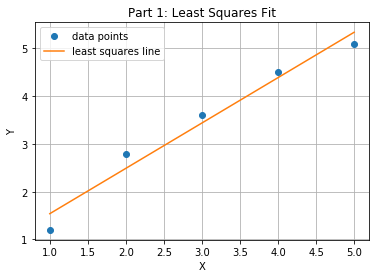

Part 2 -> Slope: -0.016515596829211113, Intercept: 0.569473655814626


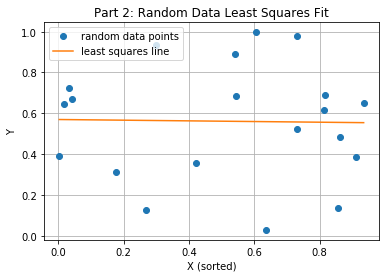

Part 2 note: since X and Y are random, there is no real linear relationship, so the fit is not very meaningful.
Part 3: Original line: m=2.5, b=-0.4
Part 3: Fitted line : m=2.8654046300716405, c=-0.48942654539300623


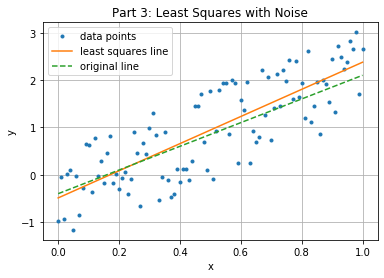

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Part 1 

# given data points
X = np.array([1, 2, 3, 4, 5], dtype=float)
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1], dtype=float)

# build the design matrix [X  1]
A = np.vstack([X, np.ones(len(X))]).T

# solve least squares problem
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Part 1 -> Slope: {m}, Intercept: {c}")

# create line for plotting
x_line = np.linspace(X.min(), X.max(), 200)
y_line = m * x_line + c

# plot original points and best-fit line
plt.figure()
plt.plot(X, Y, "o", label="data points")
plt.plot(x_line, y_line, "-", label="least squares line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Part 1: Least Squares Fit")
plt.legend()
plt.grid(True)
plt.show()


# Part 2 
# Randomize X and Y, sort X, rerun least squares

rng = np.random.default_rng(0)

# random X and Y vectors
X2 = rng.random(20)
Y2 = rng.random(20)

# we sort X and keep Y paired correctly
idx = np.argsort(X2)
X2 = X2[idx]
Y2 = Y2[idx]

# least squares again
A2 = np.vstack([X2, np.ones(len(X2))]).T
m2, c2 = np.linalg.lstsq(A2, Y2, rcond=None)[0]
print(f"Part 2 -> Slope: {m2}, Intercept: {c2}")

# plot random points and fit
x_line2 = np.linspace(X2.min(), X2.max(), 200)
y_line2 = m2 * x_line2 + c2

plt.figure()
plt.plot(X2, Y2, "o", label="random data points")
plt.plot(x_line2, y_line2, "-", label="least squares line")
plt.xlabel("X (sorted)")
plt.ylabel("Y")
plt.title("Part 2: Random Data Least Squares Fit")
plt.legend()
plt.grid(True)
plt.show()

# explanation 
print("Part 2 note: since X and Y are random, there is no real linear relationship, so the fit is not very meaningful.")


# Part 3 
# Make my own line, add +/- random noise, rerun LS

# x values from 0 to 1 in steps of 0.01 
x3 = np.arange(0, 1.01, 0.01)

# choose my own linear equation y = mx + b
m_true = 2.5
b_true = -0.4

# random perturbation between 0 and 1 with + or - sign
err_mag = rng.random(len(x3))
err_sign = rng.choice([-1, 1], size=len(x3))
err = err_sign * err_mag

# noisy y values
y3 = m_true * x3 + b_true + err

# least squares fit on noisy data
A3 = np.vstack([x3, np.ones(len(x3))]).T
m3, c3 = np.linalg.lstsq(A3, y3, rcond=None)[0]

print(f"Part 3: Original line: m={m_true}, b={b_true}")
print(f"Part 3: Fitted line : m={m3}, c={c3}")

# line for plotting
x_line3 = np.linspace(x3.min(), x3.max(), 300)
y_fit3 = m3 * x_line3 + c3
y_true3 = m_true * x_line3 + b_true

# plot noisy points and best-fit line 
plt.figure()
plt.plot(x3, y3, "o", markersize=3, label="data points")
plt.plot(x_line3, y_fit3, "-", label="least squares line")
plt.plot(x_line3, y_true3, "--", label="original line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Part 3: Least Squares with Noise")
plt.legend()
plt.grid(True)
plt.show()